Encabezados detectados en el archivo: ['Tiempo simulacion [s]', 'Voltaje [V]', 'Intensidad [A]', 'resistencia [Ohm]']
El valor máximo de resistencia es 450.69767441860427 y el valor mínimo distinto de cero es 39.95876288659796.


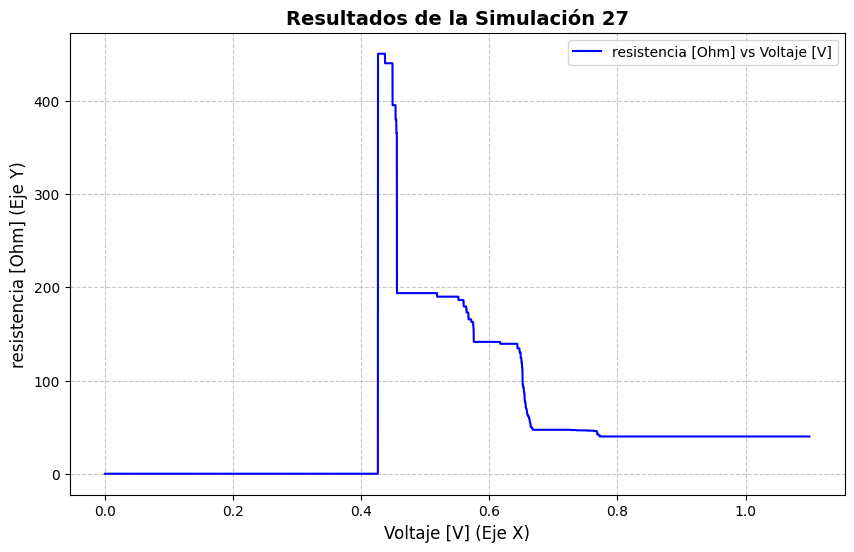

In [ ]:
# 1. Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# 2. Configuración del usuario
ruta_archivo = r"Results\simulation_12\Data_pp_set_12.npz"

# Escribe aquí los nombres exactos de las variables tal como aparecen en tu archivo
nombre_var_x = "Voltaje [V]"  # REEMPLAZA ESTO
nombre_var_y = "resistencia [Ohm]"  # REEMPLAZA ESTO

try:
    # 3. Cargar el archivo .npz
    datos_npz = np.load(ruta_archivo)

    # 4. Procesar el Header (Encabezados)
    # Extraemos el texto del header
    header_crudo = str(datos_npz["header"][0])

    # .strip() elimina espacios accidentales al principio o final del nombre
    nombres_columnas = [nombre.strip() for nombre in header_crudo.split(",")]

    print(f"Encabezados detectados en el archivo: {nombres_columnas}")

    # 5. Buscar las posiciones de las variables elegidas
    indice_x = nombres_columnas.index(nombre_var_x)
    indice_y = nombres_columnas.index(nombre_var_y)

    # 6. Extraer los datos numéricos de la matriz principal
    matriz_datos = datos_npz["datos"]

    eje_x = matriz_datos[:, indice_x]
    eje_y = matriz_datos[:, indice_y]
    
    print(f"El valor máximo de resistencia es {np.max(eje_y)} y el valor mínimo distinto de cero es {np.min(eje_y[eje_y > 0])}.")

    # 7. Crear y configurar el gráfico
    plt.figure(figsize=(10, 6))

    plt.plot(eje_x, eje_y, linestyle="-", color="blue", label=f"{nombre_var_y} vs {nombre_var_x}")

    plt.title("Resultados de la Simulación 27", fontsize=14, fontweight="bold")
    plt.xlabel(f"{nombre_var_x} (Eje X)", fontsize=12)
    plt.ylabel(f"{nombre_var_y} (Eje Y)", fontsize=12)

    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

    # Renderizar el gráfico final
    plt.show()

except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo en '{ruta_archivo}'.")
except KeyError:
    print("Error: El archivo no tiene la estructura esperada (faltan los arreglos 'datos' o 'header').")
except ValueError:
    print("\nError: Uno de los nombres de variable que escribiste no coincide con los extraídos.")
    print("Por favor, revisa la lista de 'Encabezados detectados' arriba y asegúrate de que esté bien escrito.")

print()

Vamos a realizar una refactorización guiada para que el espacio de simulación sea rectangular. 

Contexto Crítico y Anclaje Semántico:
1. La matriz que vamos a inicializar es el futuro 'actual_state', la variable central de toda la simulación. 
2. 'actual_state' representa ÚNICAMENTE el dieléctrico (material aislante). Los electrodos NO están incluidos en sus índices; son límites externos.
3. Estructura Física: [Electrodo Izquierdo] | [Matriz actual_state (Dieléctrico)] | [Electrodo Derecho].
4. Eje X (Horizontal/Profundidad): 'device_size_x'. Corresponde estrictamente a shape[0] en la variable actual_state.
5. Eje Y (Vertical/Ancho): 'device_size_y'. Corresponde estrictamente a shape[1] en la variable actual_state.

EJEMPLO NUMÉRICO DE REFERENCIA:
- Si configuramos una distancia entre electrodos (device_size_x) de 10 nm.
- Y un ancho de dispositivo (device_size_y) de 12.5 nm.
- Con un tamaño de celda (atom_size) de 0.25 nm.
- LA MATRIZ 'actual_state' DEBE TENER UN SHAPE DE (40, 50). 
  (Donde 40 = 10/0.25 y 50 = 12.5/0.25). Cada celda sigue siendo un cuadrado de 0.25 x 0.25 nm.

Tareas del Paso 1:
- En 'Simulation.py' -> 'SimulationParameters': Sustituye 'device_size' por 'device_size_x' (horizontal) y 'device_size_y' (vertical). Calcula 'x_size' e 'y_size' como enteros en el __post_init__.
- El número máximo de vacantes debe ser proporcional al área del dieléctrico: int(0.95 * x_size * y_size).
- En 'Init_simulation.py': Calcula 'eje_x' y 'eje_y' usando los nuevos parámetros físicos y atom_size. La matriz generada (que será cargada como 'actual_state') debe crearse como 'np.zeros((eje_x, eje_y))'.

Regla de Ejecución: Genera el código COMPLETO de las clases y funciones afectadas. ESTÁ PROHIBIDO usar marcadores de omisión (# ...). No intentes simular resultados, implementa la estructura lógica descrita.